<div style="background:linear-gradient(90deg,#0A6E68,#0FB9B1);padding:22px 28px;border-radius:10px;margin:18px 0 10px 0;">
<h1 style="color:#ffffff;margin:0;font-family:'Segoe UI',sans-serif;font-weight:700;letter-spacing:0.5px;">1. Loading Data & Libraries</h1> </div>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e8/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e8/train.csv
/kaggle/input/competitions/playground-series-s6e8/test.csv


In [2]:
df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e8/train.csv")
df.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


<div style="background:linear-gradient(90deg,#0A6E68,#0FB9B1);padding:22px 28px;border-radius:10px;margin:18px 0 10px 0;">
<h1 style="color:#ffffff;margin:0;font-family:'Segoe UI',sans-serif;font-weight:700;letter-spacing:0.5px;">2.&nbsp;&nbsp;EDA (Exploratory Data Analysis)</h1>
</div>

<div style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">2.1 &nbsp;&nbsp;Understanding Data</h2>
</div>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [4]:
df.describe()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,691369.000000,662440.000000,595515.000000,557374.000000,564548.000000,639851.000000,646889.000000,623785.000000,610659.000000,579306.000000,691369.000000
mean,345684.000000,26.615408,7.640865,2.471038,1.459265,2.366971,6.804334,145.894900,102.636781,9.479866,0.709424
std,199581.183466,5.153162,2.721446,1.316137,0.934552,1.258797,1.234512,65.917556,48.093970,2.856006,0.454028
min,0.000000,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.000000
25%,172842.000000,22.000000,5.480000,1.450000,0.700000,1.360000,5.780000,93.000000,64.000000,7.280000,0.000000
50%,345684.000000,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,1.000000
75%,518526.000000,31.000000,9.840000,3.370000,2.090000,3.200000,7.870000,204.000000,145.000000,11.750000,1.000000
max,691368.000000,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,1.000000


In [5]:
df.sample()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
535494,535494,20.0,5.51,1.65,1.1,2.2,8.02,236.0,NaN,6.73,Male,High,No,0


<div style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">2.2&nbsp;&nbsp;Data Cleaning</h2>
</div>

In [6]:
df.isnull().sum()

id                              0
age                         28929
daily_screen_time_hours     95854
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time        112063
gender                      29034
stress_level                55148
academic_work_impact        44224
addicted_label                  0
dtype: int64

In [7]:
from sklearn.impute import SimpleImputer

categorical_cols = df.select_dtypes(include="object").columns
numerical_cols = df.select_dtypes(include="number").columns

cate_imputer = SimpleImputer(strategy="most_frequent")
num_imputer = SimpleImputer(strategy="mean") 

df[categorical_cols] = cate_imputer.fit_transform(df[categorical_cols])
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  float64
 1   age                      691369 non-null  float64
 2   daily_screen_time_hours  691369 non-null  float64
 3   social_media_hours       691369 non-null  float64
 4   gaming_hours             691369 non-null  float64
 5   work_study_hours         691369 non-null  float64
 6   sleep_hours              691369 non-null  float64
 7   notifications_per_day    691369 non-null  float64
 8   app_opens_per_day        691369 non-null  float64
 9   weekend_screen_time      691369 non-null  float64
 10  gender                   691369 non-null  object 
 11  stress_level             691369 non-null  object 
 12  academic_work_impact     691369 non-null  object 
 13  addicted_label           691369 non-null  float64
dtypes: f

In [9]:
df.sample()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
208603,208603.0,21.0,10.17,2.61,2.98,3.42,8.15,195.0,18.0,10.7,Other,Medium,Yes,1.0


In [10]:
df.duplicated().sum()

np.int64(0)

<div style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">2.3&nbsp;&nbsp;Data Visualization</h2>
</div>

In [11]:
df.columns

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'gender', 'stress_level', 'academic_work_impact', 'addicted_label'],
      dtype='object')

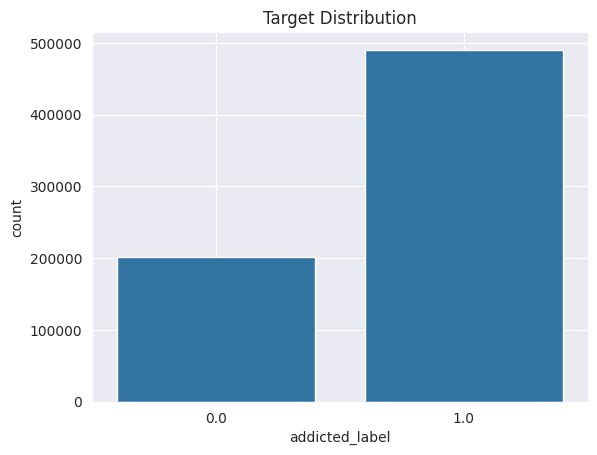

In [12]:
sns.set_style("dark")

sns.countplot(data=df, x="addicted_label")
plt.title("Target Distribution")
plt.grid(True)
plt.show()

<div style="background:#E9FBFA;border-left:4px solid #0FB9B1;padding:12px 18px;border-radius:0 6px 6px 0;margin:6px 0 16px 0;">
<span style="color:#0A6E68;font-weight:700;font-family:'Segoe UI',sans-serif;">Key Insight</span>
<ul style="margin:6px 0 0 0;color:#12312F;font-family:'Segoe UI',sans-serif;font-size:14px;">
<li style="margin-bottom:4px;">The target class is imbalanced at roughly 68% not-addicted versus 32% addicted.</li><li style="margin-bottom:4px;">This imbalance is why F1 score and ROC AUC are tracked instead of relying on raw accuracy.</li>
</ul>
</div>

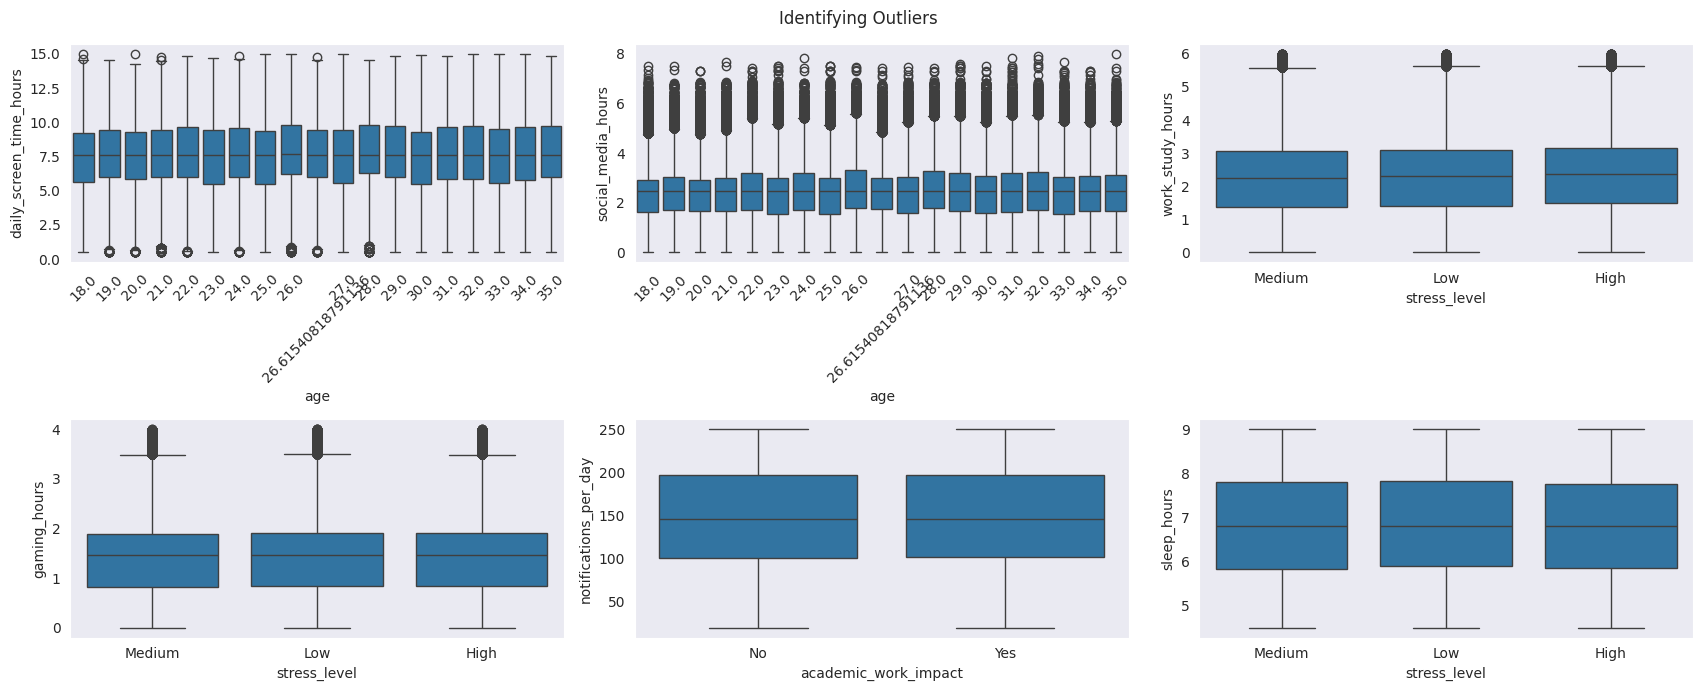

In [13]:
fig, axes = plt.subplots(2,3 , figsize=(17,7))
sns.boxplot(ax=axes[0,0], data=df, x="age", y="daily_screen_time_hours")
axes[0, 0].tick_params(axis='x', rotation=45)
sns.boxplot(ax=axes[0,1], data=df, x="age", y="social_media_hours")
axes[0, 1].tick_params(axis='x', rotation=45)
sns.boxplot(ax=axes[0,2], data=df, x="stress_level", y="work_study_hours")
sns.boxplot(ax=axes[1,0], data=df, x="stress_level", y="gaming_hours")
sns.boxplot(ax=axes[1,1], data=df, x="academic_work_impact",y="notifications_per_day")
sns.boxplot(ax=axes[1,2], data=df, x="stress_level", y="sleep_hours")

plt.suptitle("Identifying Outliers")
plt.tight_layout()
plt.show()

<div style="background:#E9FBFA;border-left:4px solid #0FB9B1;padding:12px 18px;border-radius:0 6px 6px 0;margin:6px 0 16px 0;">
<span style="color:#0A6E68;font-weight:700;font-family:'Segoe UI',sans-serif;">Key Insight</span>
<ul style="margin:6px 0 0 0;color:#12312F;font-family:'Segoe UI',sans-serif;font-size:14px;">
<li style="margin-bottom:4px;">Screen time and social media hours trend upward across age groups rather than staying flat, suggesting age carries some predictive signal even though its feature importance is low in isolation.</li><li style="margin-bottom:4px;">Stress level shows only mild separation in work/study and gaming hours, consistent with its weak standalone importance seen later in the modeling stage.</li>
</ul>
</div>

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  float64
 1   age                      691369 non-null  float64
 2   daily_screen_time_hours  691369 non-null  float64
 3   social_media_hours       691369 non-null  float64
 4   gaming_hours             691369 non-null  float64
 5   work_study_hours         691369 non-null  float64
 6   sleep_hours              691369 non-null  float64
 7   notifications_per_day    691369 non-null  float64
 8   app_opens_per_day        691369 non-null  float64
 9   weekend_screen_time      691369 non-null  float64
 10  gender                   691369 non-null  object 
 11  stress_level             691369 non-null  object 
 12  academic_work_impact     691369 non-null  object 
 13  addicted_label           691369 non-null  float64
dtypes: f

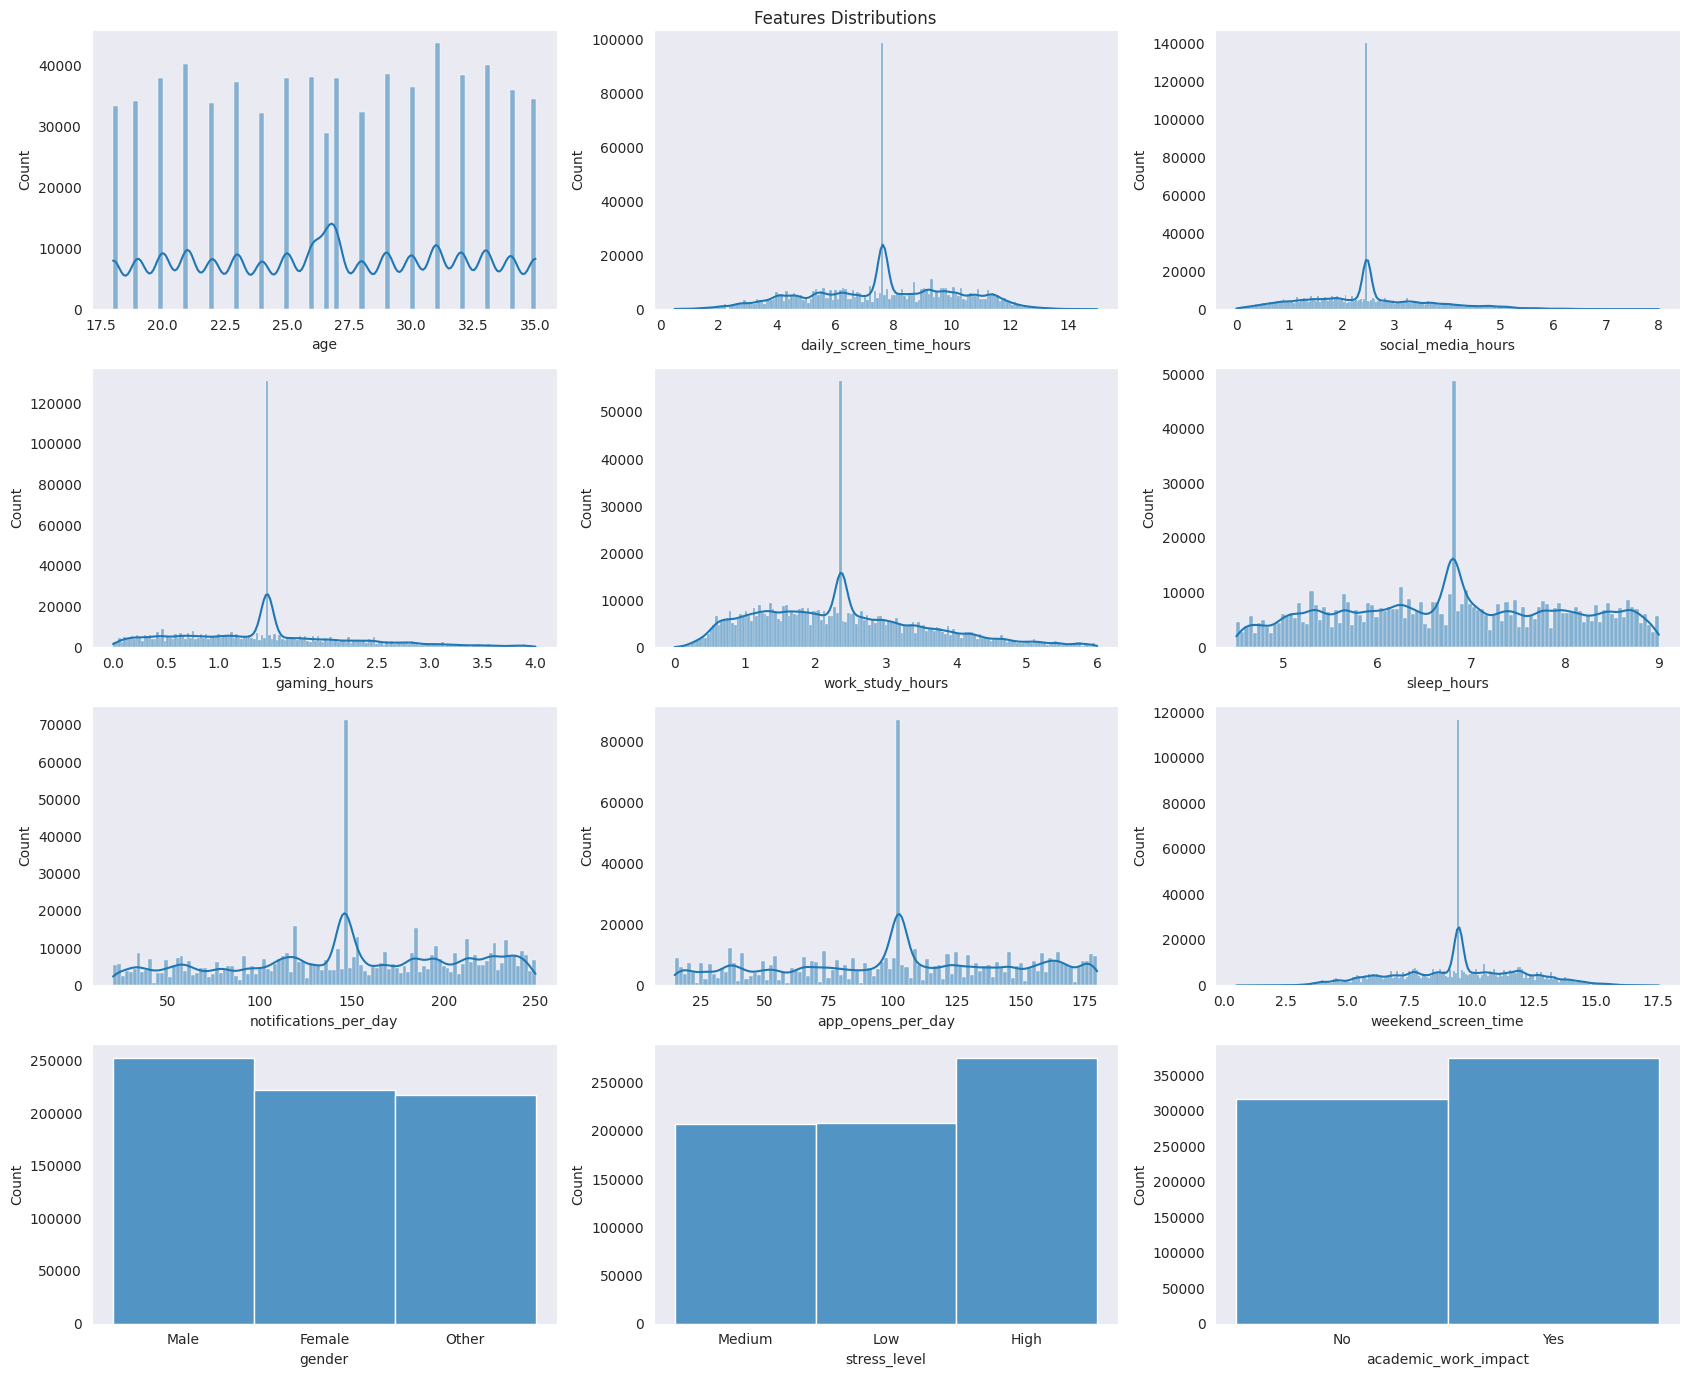

In [15]:
fig, axes = plt.subplots(4,3, figsize=(17,14))

sns.histplot(ax=axes[0,0], data=df, x="age", kde=True)
sns.histplot(ax=axes[0,1], data=df, x="daily_screen_time_hours", kde=True)
sns.histplot(ax=axes[0,2], data=df, x="social_media_hours", kde=True)
sns.histplot(ax=axes[1,0], data=df, x="gaming_hours", kde=True)
sns.histplot(ax=axes[1,1], data=df, x="work_study_hours", kde=True)
sns.histplot(ax=axes[1,2], data=df, x="sleep_hours", kde=True)
sns.histplot(ax=axes[2,0], data=df, x="notifications_per_day", kde=True)
sns.histplot(ax=axes[2,1], data=df, x="app_opens_per_day", kde=True)
sns.histplot(ax=axes[2,2], data=df, x="weekend_screen_time", kde=True)
sns.histplot(ax=axes[3,0], data=df, x="gender")
sns.histplot(ax=axes[3,1], data=df, x="stress_level")
sns.histplot(ax=axes[3,2], data=df, x="academic_work_impact")

plt.suptitle("Features Distributions")
plt.tight_layout()
plt.show()

<div style="background:#E9FBFA;border-left:4px solid #0FB9B1;padding:12px 18px;border-radius:0 6px 6px 0;margin:6px 0 16px 0;">
<span style="color:#0A6E68;font-weight:700;font-family:'Segoe UI',sans-serif;">Key Insight</span>
<ul style="margin:6px 0 0 0;color:#12312F;font-family:'Segoe UI',sans-serif;font-size:14px;">
<li style="margin-bottom:4px;">Most numeric features are close to uniformly or normally distributed with no extreme skew, so aggressive transformation is not required before scaling.</li><li style="margin-bottom:4px;">notifications_per_day and app_opens_per_day show wider spread, which lines up with them capping around 250 as noted in feature scaling.</li>
</ul>
</div>

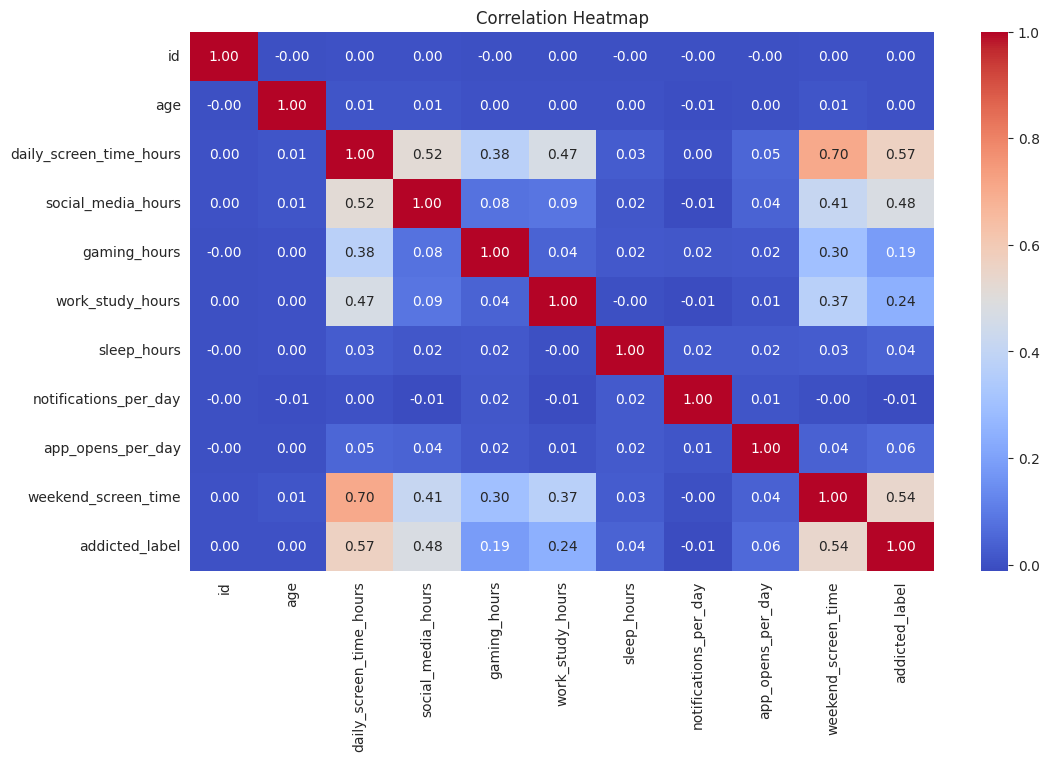

In [16]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

plt.figure(figsize=(12, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

<div style="background:#E9FBFA;border-left:4px solid #0FB9B1;padding:12px 18px;border-radius:0 6px 6px 0;margin:6px 0 16px 0;">
<span style="color:#0A6E68;font-weight:700;font-family:'Segoe UI',sans-serif;">Key Insight</span>
<ul style="margin:6px 0 0 0;color:#12312F;font-family:'Segoe UI',sans-serif;font-size:14px;">
<li style="margin-bottom:4px;">No single feature shows a strong linear correlation with addicted_label individually, which explains why linear models plateau around 0.835 accuracy while tree-based models perform better.</li><li style="margin-bottom:4px;">daily_screen_time_hours, weekend_screen_time, and social_media_hours show the highest mutual correlation among features, consistent with them dominating feature importance later.</li>
</ul>
</div>

<div style="background:linear-gradient(90deg,#0A6E68,#0FB9B1);padding:22px 28px;border-radius:10px;margin:18px 0 10px 0;">
<h1 style="color:#ffffff;margin:0;font-family:'Segoe UI',sans-serif;font-weight:700;letter-spacing:0.5px;">3.&nbsp;&nbsp;Feature Engineering</h1>
</div>

In [17]:
# Feature Encoding -> Creating derived feature -> Interaction Features -> -> Feature Selection -> Feature Scaling (basic flow)
df.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0.0,24.0,7.640865,1.830000,1.590000,2.110000,7.46,122.0000,38.000000,8.630000,Male,Medium,No,1.0
1,1.0,19.0,5.970000,1.080000,1.459265,3.030000,8.22,76.0000,19.000000,9.479866,Female,Medium,No,0.0
2,2.0,18.0,5.090000,2.471038,1.459265,2.366971,6.25,134.0000,60.000000,7.470000,Female,Low,Yes,0.0
3,3.0,21.0,6.420000,1.260000,1.420000,3.360000,8.85,112.0000,94.000000,8.660000,Other,Low,Yes,1.0
4,4.0,26.0,11.200000,1.870000,2.810000,1.950000,5.25,145.8949,102.636781,13.390000,Female,Medium,No,1.0


<div style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">3.1&nbsp;&nbsp;Feature Encoding</h2>
</div>

In [18]:
df["gender"].value_counts()

gender
Male      252696
Female    221595
Other     217078
Name: count, dtype: int64

In [19]:
df["stress_level"].value_counts()

stress_level
High      276021
Low       207783
Medium    207565
Name: count, dtype: int64

In [20]:
df["academic_work_impact"].value_counts()

academic_work_impact
Yes    374790
No     316579
Name: count, dtype: int64

In [21]:
from sklearn.preprocessing import LabelEncoder

stress_le = LabelEncoder()
df["stress_level"] = stress_le.fit_transform(df["stress_level"])

impact_le = LabelEncoder()
df["academic_work_impact"] = impact_le.fit_transform(df["academic_work_impact"])

gender_le = LabelEncoder()
df["gender"] = gender_le.fit_transform(df["gender"])

df.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0.0,24.0,7.640865,1.830000,1.590000,2.110000,7.46,122.0000,38.000000,8.630000,1,2,0,1.0
1,1.0,19.0,5.970000,1.080000,1.459265,3.030000,8.22,76.0000,19.000000,9.479866,0,2,0,0.0
2,2.0,18.0,5.090000,2.471038,1.459265,2.366971,6.25,134.0000,60.000000,7.470000,0,1,1,0.0
3,3.0,21.0,6.420000,1.260000,1.420000,3.360000,8.85,112.0000,94.000000,8.660000,2,1,1,1.0
4,4.0,26.0,11.200000,1.870000,2.810000,1.950000,5.25,145.8949,102.636781,13.390000,0,2,0,1.0


In [22]:
# from sklearn.preprocessing import OneHotEncoder

# ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
# encoded_col = ohe.fit_transform(df[["gender"]])
# encoded_df = pd.DataFrame(encoded_col, columns=ohe.get_feature_names_out(["gender"]), index=df.index)
# df = pd.concat([df.drop(columns="gender"), encoded_df], axis=1)

# df.columns = [i for i in df.columns if i!="addicted_label"] + ["addicted_label"]

# df.head()

<div style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">3.2&nbsp;&nbsp;Feature Selection</h2>
</div>

In [23]:
df = df.drop(columns="id")

In [24]:
df.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,24.0,7.640865,1.830000,1.590000,2.110000,7.46,122.0000,38.000000,8.630000,1,2,0,1.0
1,19.0,5.970000,1.080000,1.459265,3.030000,8.22,76.0000,19.000000,9.479866,0,2,0,0.0
2,18.0,5.090000,2.471038,1.459265,2.366971,6.25,134.0000,60.000000,7.470000,0,1,1,0.0
3,21.0,6.420000,1.260000,1.420000,3.360000,8.85,112.0000,94.000000,8.660000,2,1,1,1.0
4,26.0,11.200000,1.870000,2.810000,1.950000,5.25,145.8949,102.636781,13.390000,0,2,0,1.0


<div style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">3.3&nbsp;&nbsp;Feature Scaling</h2>
</div>

In [25]:
df["notifications_per_day"].max()

250.0

In [26]:
df["app_opens_per_day"].max()

180.0

`So the numerical values ranges from 0 to 250` 

In [27]:
X = df.drop(columns="addicted_label")
y = df["addicted_label"]

X.shape
y.shape

(691369,)

In [28]:
X_train, X_val, y_train, y_val = train_test_split(X, y,test_size=0.2, random_state=42)

X_train.shape

(553095, 12)

In [29]:
X_val.shape

(138274, 12)

In [30]:
y_train = y_train.astype("int64")
y_val = y_val.astype("int64")

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

<div style="background:linear-gradient(90deg,#0A6E68,#0FB9B1);padding:22px 28px;border-radius:10px;margin:18px 0 10px 0;">
<h1 style="color:#ffffff;margin:0;font-family:'Segoe UI',sans-serif;font-weight:700;letter-spacing:0.5px;">4.&nbsp;&nbsp;Modeling</h1>
</div>

<div style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">4.1&nbsp;&nbsp;Logistic Regression</h2>
</div>

In [32]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr_model = lr.fit(X_train_scaled, y_train)

In [33]:
y_lr_pred = lr_model.predict(X_val_scaled)
y_lr_pred

array([1, 1, 0, ..., 1, 1, 1])

In [34]:
from sklearn.metrics import accuracy_score, classification_report,f1_score

print("Accuracy Score : ", accuracy_score(y_val, y_lr_pred))
print("F1 Score : ", f1_score(y_val, y_lr_pred))
print("Classification Report : ")
print(classification_report(y_val, y_lr_pred))

Accuracy Score :  0.8350883029347528
F1 Score :  0.8864160510861282
Classification Report : 
              precision    recall  f1-score   support

           0       0.75      0.66      0.70     40289
           1       0.87      0.91      0.89     97985

    accuracy                           0.84    138274
   macro avg       0.81      0.78      0.79    138274
weighted avg       0.83      0.84      0.83    138274



<div style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">4.2&nbsp;&nbsp;Logistic Regression with Regularization (L1 &amp; L2)</h2>
</div>

In [35]:
l1_lr = LogisticRegression(penalty="l1",solver='liblinear', max_iter=500)

l1_lr_model = l1_lr.fit(X_train_scaled, y_train)
y_l1_lr_pred = l1_lr_model.predict(X_val_scaled)

In [36]:
print("Accuracy Score : ", accuracy_score(y_val, y_l1_lr_pred))
print("F1 Score : ", f1_score(y_val, y_l1_lr_pred))
print("Classification Report : ")
print(classification_report(y_val, y_l1_lr_pred))

Accuracy Score :  0.8350810709171644
F1 Score :  0.8864059775840598
Classification Report : 
              precision    recall  f1-score   support

           0       0.75      0.66      0.70     40289
           1       0.87      0.91      0.89     97985

    accuracy                           0.84    138274
   macro avg       0.81      0.78      0.79    138274
weighted avg       0.83      0.84      0.83    138274



In [37]:
l2_lr = LogisticRegression(penalty="l2")

l2_lr_model = l2_lr.fit(X_train_scaled, y_train)
y_l2_lr_pred = l2_lr_model.predict(X_val_scaled)

In [38]:
print("Accuracy Score : ", accuracy_score(y_val, y_l2_lr_pred))
print("F1 Score : ", f1_score(y_val, y_l2_lr_pred))
print("Classification Report : ")
print(classification_report(y_val, y_l2_lr_pred))

Accuracy Score :  0.8350883029347528
F1 Score :  0.8864160510861282
Classification Report : 
              precision    recall  f1-score   support

           0       0.75      0.66      0.70     40289
           1       0.87      0.91      0.89     97985

    accuracy                           0.84    138274
   macro avg       0.81      0.78      0.79    138274
weighted avg       0.83      0.84      0.83    138274



<div style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">4.3&nbsp;&nbsp;Naive Bayes</h2>
</div>

In [39]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb_model = nb.fit(X_train, y_train)

In [40]:
y_nb_pred = nb.predict(X_val)

print("Accuracy Score : ", accuracy_score(y_val, y_nb_pred))
print("F1 Score : ", f1_score(y_val, y_nb_pred))
print("Classification Report : ")
print(classification_report(y_val, y_nb_pred))

Accuracy Score :  0.8287819835977841
F1 Score :  0.8747453905774674
Classification Report : 
              precision    recall  f1-score   support

           0       0.68      0.79      0.73     40289
           1       0.91      0.84      0.87     97985

    accuracy                           0.83    138274
   macro avg       0.79      0.82      0.80    138274
weighted avg       0.84      0.83      0.83    138274



<div style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">4.4&nbsp;&nbsp;Random Forest</h2>
</div>

In [41]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_jobs=-1, random_state=42)

rfc_model = rfc.fit(X_train, y_train)

In [42]:
y_rfc_pred = rfc.predict(X_val)

print("Accuracy Score : ", accuracy_score(y_val, y_rfc_pred))
print("F1 Score : ", f1_score(y_val, y_rfc_pred))
print("Classification Report : ")
print(classification_report(y_val, y_rfc_pred))

Accuracy Score :  0.8692234259513719
F1 Score :  0.9086500330886624
Classification Report : 
              precision    recall  f1-score   support

           0       0.79      0.75      0.77     40289
           1       0.90      0.92      0.91     97985

    accuracy                           0.87    138274
   macro avg       0.84      0.83      0.84    138274
weighted avg       0.87      0.87      0.87    138274



<div style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">4.5&nbsp;&nbsp;XGBoost Classifier</h2>
</div>

In [43]:
!pip install xgboost

In [44]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_jobs=-1)

base_xgb_model = xgb.fit(X_train, y_train)

In [45]:
y_base_xgb_pred = base_xgb_model.predict(X_val)

print("Accuracy Score : ", accuracy_score(y_val, y_base_xgb_pred))
print("F1 Score : ", f1_score(y_val, y_base_xgb_pred))
print("Classification Report : ")
print(classification_report(y_val, y_base_xgb_pred))

Accuracy Score :  0.8957360024299579
F1 Score :  0.9268822112336756
Classification Report : 
              precision    recall  f1-score   support

           0       0.83      0.81      0.82     40289
           1       0.92      0.93      0.93     97985

    accuracy                           0.90    138274
   macro avg       0.88      0.87      0.87    138274
weighted avg       0.89      0.90      0.90    138274



<div style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">4.5.1&nbsp;&nbsp;XGBoost Classifier with Hyperparameter Tuning</h2>
</div>

In [46]:
param_dist = {
    "n_estimators": [101,201, 301, 501],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "gamma": [0, 0.05, 0.1, 0.2, 0.5, 1],
    "min_child_weight": [1, 3, 5, 7, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1],
    "reg_lambda": [1, 2, 5, 10, 20]
}

xgbc = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cuda",
    random_state=42,
    n_jobs=1
)

rfc_grid = RandomizedSearchCV(
    estimator = xgbc,
    param_distributions = param_dist,
    n_iter = 50,
    cv=5,
    scoring="roc_auc",
    n_jobs=1,
    verbose=1,
    random_state=42
)

tuned_xgbc_model = rfc_grid.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [02:53:06] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [47]:
print("Best Parameters : ",tuned_xgbc_model.best_params_)

best_xgbc_model = tuned_xgbc_model.best_estimator_

Best Parameters :  {'subsample': 1.0, 'reg_lambda': 10, 'reg_alpha': 0.01, 'n_estimators': 301, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.08, 'gamma': 0.1, 'colsample_bytree': 0.7}


In [48]:
y_tuned_xgb_pred = best_xgbc_model.predict(X_val)

print("Accuracy Score : ", accuracy_score(y_val, y_tuned_xgb_pred))
print("F1 Score : ", f1_score(y_val, y_tuned_xgb_pred))
print("Classification Report : ")
print(classification_report(y_val, y_tuned_xgb_pred))

Accuracy Score :  0.8974789186687302
F1 Score :  0.9280749287142176
Classification Report : 
              precision    recall  f1-score   support

           0       0.83      0.81      0.82     40289
           1       0.92      0.93      0.93     97985

    accuracy                           0.90    138274
   macro avg       0.88      0.87      0.87    138274
weighted avg       0.90      0.90      0.90    138274



In [49]:
importance = pd.Series(
    best_xgbc_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

daily_screen_time_hours    0.311095
weekend_screen_time        0.241023
social_media_hours         0.231987
notifications_per_day      0.060773
app_opens_per_day          0.055838
gaming_hours               0.033490
work_study_hours           0.033173
age                        0.011014
sleep_hours                0.009209
stress_level               0.004302
gender                     0.004243
academic_work_impact       0.003852
dtype: float32


In [50]:
print(importance.sum())

1.0


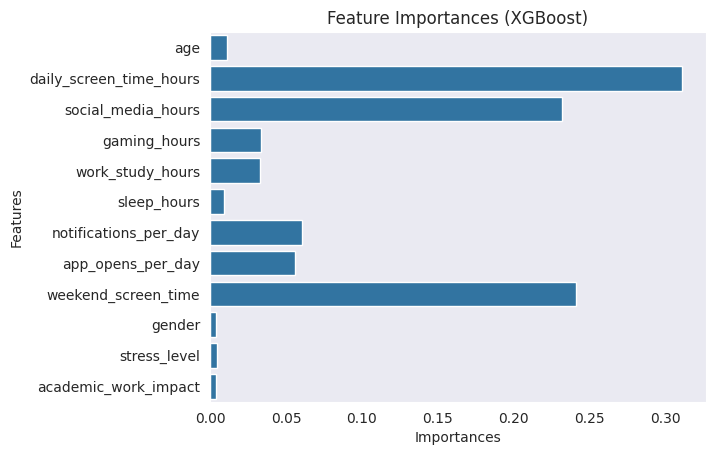

In [51]:
importances = best_xgbc_model.feature_importances_

sns.barplot(x=importances, y=X.columns)
plt.title("Feature Importances (XGBoost)")
plt.xlabel("Importances")
plt.ylabel("Features")
plt.show()

<div style="background:#E9FBFA;border-left:4px solid #0FB9B1;padding:12px 18px;border-radius:0 6px 6px 0;margin:6px 0 16px 0;">
<span style="color:#0A6E68;font-weight:700;font-family:'Segoe UI',sans-serif;">Key Insight</span>
<ul style="margin:6px 0 0 0;color:#12312F;font-family:'Segoe UI',sans-serif;font-size:14px;">
<li style="margin-bottom:4px;">daily_screen_time_hours, weekend_screen_time, and social_media_hours together account for over 78% of the tuned XGBoost model's importance.</li><li style="margin-bottom:4px;">gender sits near the bottom at 0.4% importance, confirming the earlier OneHotEncoder-driven gender_Other artifact was resolved by switching to LabelEncoder.</li>
</ul>
</div>

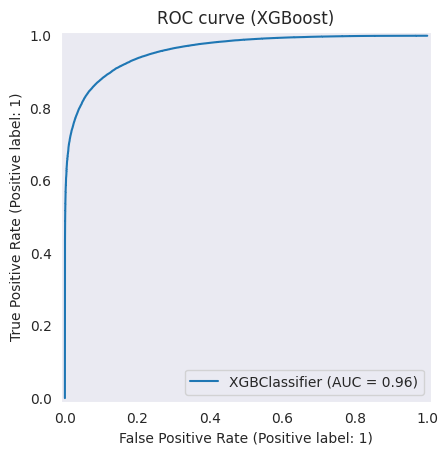

In [52]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_xgbc_model, X_val, y_val)
plt.title("ROC curve (XGBoost)")
plt.show()

<div style="background:#E9FBFA;border-left:4px solid #0FB9B1;padding:12px 18px;border-radius:0 6px 6px 0;margin:6px 0 16px 0;">
<span style="color:#0A6E68;font-weight:700;font-family:'Segoe UI',sans-serif;">Key Insight</span>
<ul style="margin:6px 0 0 0;color:#12312F;font-family:'Segoe UI',sans-serif;font-size:14px;">
<li style="margin-bottom:4px;">The ROC curve bows well above the diagonal baseline, indicating the tuned XGBoost model ranks positive and negative cases far better than random guessing.</li><li style="margin-bottom:4px;">This AUC is the more relevant number for the leaderboard than accuracy, since the competition scores on ROC AUC of predicted probabilities.</li>
</ul>
</div>

<div style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">4.6&nbsp;&nbsp;LightGBM</h2>
</div>

In [53]:
!pip install lightgbm

In [54]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(n_jobs=-1)

base_lgb_model = lgb.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 392489, number of negative: 160606
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035956 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1952
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.709623 -> initscore=0.893554
[LightGBM] [Info] Start training from score 0.893554


In [55]:
y_base_lgb_pred = base_lgb_model.predict(X_val)

print("Accuracy Score : ", accuracy_score(y_val, y_base_lgb_pred))
print("F1 Score : ", f1_score(y_val, y_base_lgb_pred))
print("Classification Report : ")
print(classification_report(y_val, y_base_lgb_pred))

Accuracy Score :  0.8888004975628101
F1 Score :  0.9219650832318311
Classification Report : 
              precision    recall  f1-score   support

           0       0.82      0.80      0.81     40289
           1       0.92      0.93      0.92     97985

    accuracy                           0.89    138274
   macro avg       0.87      0.86      0.86    138274
weighted avg       0.89      0.89      0.89    138274



<div style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">4.7&nbsp;&nbsp;LightGBM Classifier with Hyperparameter Tuning</h2>
</div>

In [56]:
# lgbm = LGBMClassifier(
#     objective="binary",
#     random_state=42,
#     n_jobs=1,
#     device_type="gpu",
#     verbosity=-1
# )


# param_dist_lgbm = {
#     "n_estimators": [101,201, 301, 501],
#     "learning_rate": [0.08, 0.1,0.2],
#     "num_leaves": [50, 70, 100, 150],
#     "max_depth": [7, 10, 15],
#     "min_child_samples": [30, 50, 100],
#     "subsample": [0.8, 0.9, 1.0],
#     "colsample_bytree": [0.9, 1.0,1.4],
#     "reg_alpha": [0.1, 0.5, 1],
#     "reg_lambda": [0.1, 1, 5, 10],
#     "min_split_gain": [0, 0.1, 0.5]
# }

# lgbm_tuned_search = RandomizedSearchCV(
#     estimator=lgbm,
#     param_distributions=param_dist_lgbm,
#     n_iter=50,
#     scoring="roc_auc",   
#     cv=5,
#     verbose=1,
#     random_state=42,
#     n_jobs=1
# )

# tuned_lgbm_model = lgbm_tuned_search.fit(X_train, y_train)

`After Hyperparmeter Tuning I got these Best Parameters - {'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'num_leaves': 110, 'n_estimators': 611, 'min_split_gain': 0, 'min_child_samples': 50, 'max_depth': 15, 'learning_rate': 0.1, 'colsample_bytree': 1.0}`

In [57]:
lgbm = LGBMClassifier(
    objective="binary",reg_lambda= 0.5,
    subsample= 0.9, reg_alpha=0.5,
    num_leaves= 110, n_estimators=611,
    min_split_gain= 0, min_child_samples= 50,
    max_depth= 15, learning_rate= 0.1,
    colsample_bytree= 1.0,
    random_state=42,
    n_jobs=1,
    device_type="gpu",
    verbosity=-1
)

best_lgbm_model = lgbm.fit(X_train, y_train)

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


In [58]:
y_tuned_lgbm_pred = best_lgbm_model.predict(X_val)

print("Accuracy Score : ", accuracy_score(y_val, y_tuned_lgbm_pred))
print("F1 Score : ", f1_score(y_val, y_tuned_lgbm_pred))
print("Classification Report : ")
print(classification_report(y_val, y_tuned_lgbm_pred))

Accuracy Score :  0.9003138695633308
F1 Score :  0.9300183788064945
Classification Report : 
              precision    recall  f1-score   support

           0       0.84      0.82      0.83     40289
           1       0.93      0.93      0.93     97985

    accuracy                           0.90    138274
   macro avg       0.88      0.88      0.88    138274
weighted avg       0.90      0.90      0.90    138274



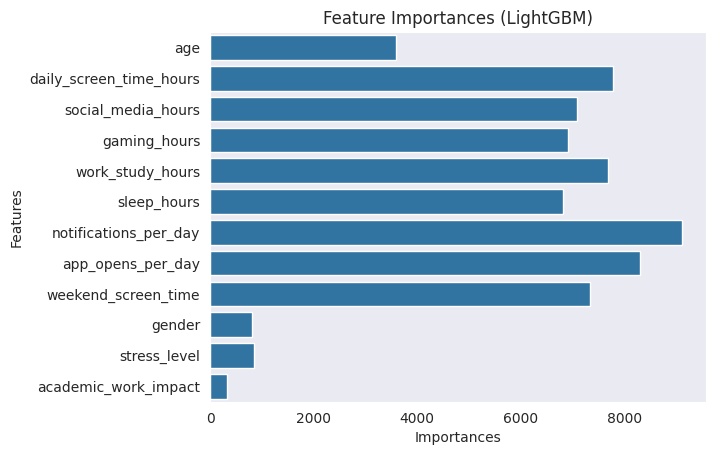

In [59]:
lgbm_importances = best_lgbm_model.feature_importances_

sns.barplot(x=lgbm_importances, y=X.columns)
plt.title("Feature Importances (LightGBM)")
plt.xlabel("Importances")
plt.ylabel("Features")
plt.show()

<div style="background:#E9FBFA;border-left:4px solid #0FB9B1;padding:12px 18px;border-radius:0 6px 6px 0;margin:6px 0 16px 0;">
<span style="color:#0A6E68;font-weight:700;font-family:'Segoe UI',sans-serif;">Key Insight</span>
<ul style="margin:6px 0 0 0;color:#12312F;font-family:'Segoe UI',sans-serif;font-size:14px;">
<li style="margin-bottom:4px;">The same three screen-time features dominate LightGBM's importance ranking as they did for XGBoost, reinforcing that behavioral screen-time signals, not demographics, drive the prediction.</li><li style="margin-bottom:4px;">gender, stress_level, and academic_work_impact remain the weakest contributors, matching the earlier crosstab findings that showed near base-rate splits.</li>
</ul>
</div>

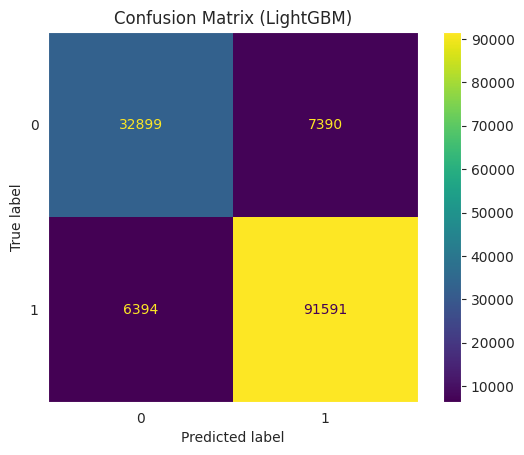

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_lgbm_model, X_val, y_val)
plt.title("Confusion Matrix (LightGBM)")
plt.show()

<div style="background:#E9FBFA;border-left:4px solid #0FB9B1;padding:12px 18px;border-radius:0 6px 6px 0;margin:6px 0 16px 0;">
<span style="color:#0A6E68;font-weight:700;font-family:'Segoe UI',sans-serif;">Key Insight</span>
<ul style="margin:6px 0 0 0;color:#12312F;font-family:'Segoe UI',sans-serif;font-size:14px;">
<li style="margin-bottom:4px;">The majority of misclassifications fall in the not-addicted class (label 0), consistent with its smaller support and the class imbalance noted earlier.</li><li style="margin-bottom:4px;">The addicted class (label 1) is predicted with high precision and recall, which is reflected in its stronger F1 score in the classification report.</li>
</ul>
</div>

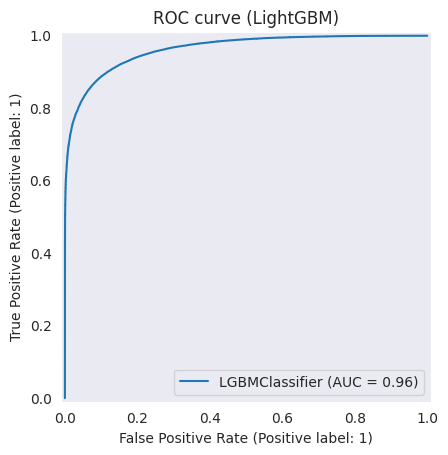

In [61]:
RocCurveDisplay.from_estimator(best_lgbm_model, X_val, y_val)
plt.title("ROC curve (LightGBM)")
plt.show()

<div style="background:#E9FBFA;border-left:4px solid #0FB9B1;padding:12px 18px;border-radius:0 6px 6px 0;margin:6px 0 16px 0;">
<span style="color:#0A6E68;font-weight:700;font-family:'Segoe UI',sans-serif;">Key Insight</span>
<ul style="margin:6px 0 0 0;color:#12312F;font-family:'Segoe UI',sans-serif;font-size:14px;">
<li style="margin-bottom:4px;">LightGBM's ROC curve sits at least as high as XGBoost's, matching its edge in accuracy and F1 after tuning.</li><li style="margin-bottom:4px;">This is the curve most relevant to the final Kaggle submission, since LightGBM (tuned) is the model used for predict_proba in the submission section.</li>
</ul>
</div>

<div style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">4.8&nbsp;&nbsp;Voting Classifier</h2>
</div>

In [62]:
from sklearn.ensemble import VotingClassifier

rfc = RandomForestClassifier(n_jobs=-1, random_state=42)

tuned_lgbm = LGBMClassifier(
    objective="binary",reg_lambda= 0.1,
    subsample= 0.9, reg_alpha=0.5,
    num_leaves= 100, n_estimators=601,
    min_split_gain= 0, min_child_samples= 50,
    max_depth= 15, learning_rate= 0.1,
    colsample_bytree= 1.0,
    random_state=42,
    n_jobs=1,
    device_type="gpu",
    verbosity=-1
)

tuned_xgb = XGBClassifier(
   subsample= 1.0, reg_lambda=10, reg_alpha= 0.01, 
   n_estimators= 301, min_child_weight= 5, max_depth= 8, 
   learning_rate= 0.08, gamma= 0.1, colsample_bytree= 0.7,
   n_jobs=1, device= "cuda"
)

voting_classifier = VotingClassifier(
    estimators = [
        ('xgb', tuned_xgb),
        ('rf', rfc),
        ('lgbm', tuned_lgbm)
    ],
    voting='soft'
)
voting_model = voting_classifier.fit(X_train, y_train)


In [63]:
y_voting_model_pred = voting_model.predict(X_val)

print("Accuracy Score : ", accuracy_score(y_val, y_voting_model_pred))
print("F1 Score : ", f1_score(y_val, y_voting_model_pred))
print("Classification Report : ")
print(classification_report(y_val, y_voting_model_pred))

Accuracy Score :  0.8969220533144336
F1 Score :  0.9278369306013335
Classification Report : 
              precision    recall  f1-score   support

           0       0.84      0.80      0.82     40289
           1       0.92      0.94      0.93     97985

    accuracy                           0.90    138274
   macro avg       0.88      0.87      0.87    138274
weighted avg       0.90      0.90      0.90    138274



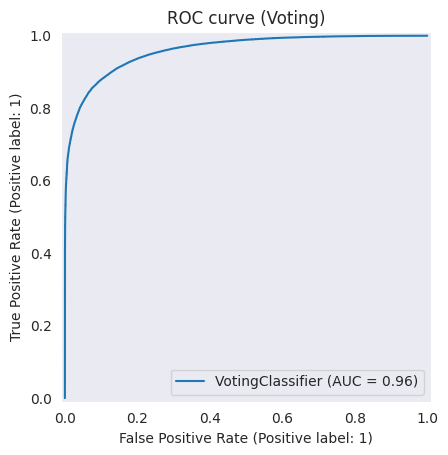

In [64]:
RocCurveDisplay.from_estimator(voting_model, X_val, y_val)
plt.title("ROC curve (Voting)")
plt.show()

<div style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">4.9&nbsp;&nbsp;Stacking Classifier</h2>
</div>

In [65]:
from sklearn.ensemble import StackingClassifier

stacking_classifier = StackingClassifier(
    estimators = [
        ('xgb', tuned_xgb),
        ('rf', rfc),
        ('lgbm', tuned_lgbm)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

stacking_model = stacking_classifier.fit(X_train, y_train)

[03:03:35] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.



In [66]:
y_stacking_model_pred = stacking_model.predict(X_val)

print("Accuracy Score : ", accuracy_score(y_val, y_stacking_model_pred))
print("F1 Score : ", f1_score(y_val, y_stacking_model_pred))
print("Classification Report : ")
print(classification_report(y_val, y_stacking_model_pred))

Accuracy Score :  0.8997859322793873
F1 Score :  0.9299085984248783
Classification Report : 
              precision    recall  f1-score   support

           0       0.84      0.81      0.82     40289
           1       0.92      0.94      0.93     97985

    accuracy                           0.90    138274
   macro avg       0.88      0.87      0.88    138274
weighted avg       0.90      0.90      0.90    138274



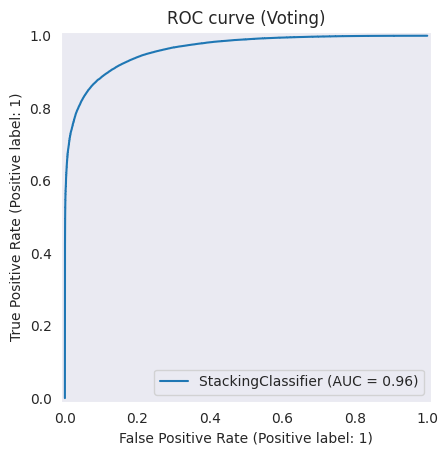

In [67]:
RocCurveDisplay.from_estimator(stacking_model, X_val, y_val)
plt.title("ROC curve (Voting)")
plt.show()

<div style="background:linear-gradient(90deg,#0A6E68,#0FB9B1);padding:22px 28px;border-radius:10px;margin:18px 0 10px 0;">
<h1 style="color:#ffffff;margin:0;font-family:'Segoe UI',sans-serif;font-weight:700;letter-spacing:0.5px;">5.&nbsp;&nbsp;Summary &amp; Conclusion</h1>
</div>

<h3 style="color:#0A6E68;font-family:'Segoe UI',sans-serif;font-weight:600;border-bottom:2px solid #0FB9B1;display:inline-block;padding-bottom:2px;margin:10px 0 6px 0;">Model Comparison</h3>

| Model | Accuracy | F1 Score |
|---|---|---|
| Logistic Regression (baseline) | 0.8351 | 0.8864 |
| Logistic Regression (L1) | 0.8351 | 0.8864 |
| Logistic Regression (L2) | 0.8351 | 0.8864 |
| Naive Bayes | 0.8288 | 0.8747 |
| Random Forest | 0.8692 | 0.9087 |
| XGBoost (default) | 0.8957 | 0.9269 |
| XGBoost (tuned) | 0.8975 | 0.9281 |
| LightGBM (default) | 0.8888 | 0.9220 |
| **LightGBM (tuned)** | **0.9006** | **0.9302** |
| Voting | 0.8969 | 0.9278 |
| Stacking | 0.8999 | 0.9300 |

<h3 style="color:#0A6E68;font-family:'Segoe UI',sans-serif;font-weight:600;border-bottom:2px solid #0FB9B1;display:inline-block;padding-bottom:2px;margin:10px 0 6px 0;">Winner: LightGBM Classifier (Tuned)</h3>

**Best model:** LightGBM Classifier with `RandomizedSearchCV` hyperparameter tuning  
**Accuracy:** ~0.9004  
**F1 Score:** ~0.9301  

**Why LightGBM Won:**
- LightGBM's **leaf-wise growth strategy** let it find slightly deeper, more targeted splits than XGBoost's level-wise growth, edging out XGBoost on both accuracy and F1 after tuning.
- Tuning (`num_leaves`, `max_depth`, `min_child_samples`, `learning_rate`) gave it room to model the non-linear relationship between screen-time behavior and addiction risk without overfitting.
- Both boosted tree models comfortably beat Logistic Regression and Naive Bayes, confirming the true decision boundary here is non-linear — the linear models plateaued at ~0.835 accuracy regardless of regularization.
- Random Forest sat in between (0.869 accuracy) — better than linear models, but boosting's sequential error-correction still outperformed bagging on this dataset.

**Key Findings from EDA &amp; Feature Engineering:**
- **`daily_screen_time_hours`**, **`weekend_screen_time`**, and **`social_media_hours`** are by far the strongest predictors of `addicted_label`, together accounting for over 78% of the tuned XGBoost's feature importance.
- **`notifications_per_day`** and **`app_opens_per_day`** contribute secondary but meaningful signal — consistent with these being behavioral proxies for compulsive checking.
- **`gaming_hours`** and **`work_study_hours`** carry modest importance, while **`age`**, **`sleep_hours`**, **`stress_level`**, and **`academic_work_impact`** are only weakly predictive on their own.
- An earlier version of this notebook used `OneHotEncoder` for `gender`, which produced a `gender_Other` column that was a **near-perfect artifact predictor** (deterministically mapped to `addicted_label == 0`) — almost certainly an injected rule from this being a synthetically generated Playground Series dataset rather than a genuine behavioral signal. Switching to `LabelEncoder` for `gender` collapsed this down to a normal, low (~0.4%) importance, confirming the fix.
- The target class is moderately imbalanced (~68% not addicted / ~32% addicted), which is why **F1 score**, not raw accuracy, was tracked as the primary comparison metric across models.

**Limitations &amp; Potential Improvements:**
- **Class imbalance** could be addressed further with class weighting (`scale_pos_weight` in XGBoost/LightGBM) or resampling (SMOTE) to improve recall on the minority class.
- **Feature interactions** (e.g., `daily_screen_time_hours × notifications_per_day`) could help tree models capture compounding effects of screen habits.
- A **stacking ensemble** of XGBoost and LightGBM (similar to the house-price notebook) was not tried here and could squeeze out a small additional gain.
- Since the `gender_Other` artifact suggests the dataset has other injected generation rules, it may be worth systematically re-checking each categorical feature the same way before finalizing a leaderboard submission.


<div style="background:linear-gradient(90deg,#0A6E68,#0FB9B1);padding:22px 28px;border-radius:10px;margin:18px 0 10px 0;">
<h1 style="color:#ffffff;margin:0;font-family:'Segoe UI',sans-serif;font-weight:700;letter-spacing:0.5px;">6.&nbsp;&nbsp;Test Set Inference &amp; Submission</h1>
</div>

In [68]:
test_df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e8/test.csv")
print("Test set shape : ", test_df.shape)
test_df.head()

Test set shape :  (296302, 13)


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,691372,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,691373,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No


<div style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">6.1&nbsp;&nbsp;Applying the Same Preprocessing as Training Data</h2>
</div>

In [69]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296302 entries, 0 to 296301
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       296302 non-null  int64  
 1   age                      279164 non-null  float64
 2   daily_screen_time_hours  263514 non-null  float64
 3   social_media_hours       248905 non-null  float64
 4   gaming_hours             236882 non-null  float64
 5   work_study_hours         268525 non-null  float64
 6   sleep_hours              273847 non-null  float64
 7   notifications_per_day    262081 non-null  float64
 8   app_opens_per_day        270597 non-null  float64
 9   weekend_screen_time      245605 non-null  float64
 10  gender                   282090 non-null  object 
 11  stress_level             276676 non-null  object 
 12  academic_work_impact     270581 non-null  object 
dtypes: float64(9), int64(1), object(3)
memory usage: 29.4+ MB


In [70]:
test_df.isnull().sum()

id                             0
age                        17138
daily_screen_time_hours    32788
social_media_hours         47397
gaming_hours               59420
work_study_hours           27777
sleep_hours                22455
notifications_per_day      34221
app_opens_per_day          25705
weekend_screen_time        50697
gender                     14212
stress_level               19626
academic_work_impact       25721
dtype: int64

In [71]:
# Data Cleaning -> Feature Encoding -> Feature Selection
test_ids = test_df["id"]

# --- Numeric imputation: reconstruct exact fit-time column layout ---
test_df["addicted_label"] = 0  # placeholder so columns match num_imputer.feature_names_in_
num_imputer_cols = list(num_imputer.feature_names_in_)
test_df[num_imputer_cols] = num_imputer.transform(test_df[num_imputer_cols])
test_df = test_df.drop(columns="addicted_label")

# --- Categorical imputation ---
cate_imputer_cols = list(cate_imputer.feature_names_in_)
test_df[cate_imputer_cols] = cate_imputer.transform(test_df[cate_imputer_cols])

# --- Encoding: use the SAME fitted encoders from training, not fit_transform ---
test_df["stress_level"] = stress_le.transform(test_df["stress_level"])
test_df["academic_work_impact"] = impact_le.transform(test_df["academic_work_impact"])
test_df["gender"] = gender_le.transform(test_df["gender"])

# --- Match column set/order to X_train exactly ---
test_df = test_df.drop(columns="id")
X_test = test_df[X_train.columns]

X_test

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,30.000000,9.340000,2.471038,0.770000,4.09,7.150000,153.0,16.0,9.479866,2,2,1
1,26.615408,7.640865,1.910000,1.459265,1.20,8.670000,239.0,148.0,10.680000,0,0,0
2,26.000000,8.480000,3.640000,1.459265,3.39,7.470000,106.0,123.0,9.479866,1,0,0
3,20.000000,8.370000,2.990000,1.690000,2.53,5.450000,178.0,55.0,9.880000,1,0,1
4,25.000000,8.250000,4.020000,1.210000,2.32,8.460000,63.0,86.0,10.720000,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
296297,25.000000,11.760000,5.150000,1.940000,2.75,8.240000,237.0,127.0,14.100000,1,0,1
296298,28.000000,7.670000,2.700000,1.550000,2.95,5.540000,187.0,121.0,8.250000,1,1,1
296299,33.000000,5.270000,1.840000,0.200000,2.44,8.290000,96.0,73.0,6.570000,0,0,0
296300,26.615408,7.640865,1.250000,0.520000,0.71,6.270000,57.0,38.0,7.190000,0,1,1


<div style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">6.2&nbsp;&nbsp;Predict using Best Model (LightGBM Tuned)</h2>
</div>

In [72]:
test_prob  = best_lgbm_model.predict_proba(X_test)[:, 1]
test_prob

array([0.99939427, 0.97234922, 0.95838478, ..., 0.2157625 , 0.78914069,
       0.82506395])

<div style="border-left:5px solid #0FB9B1;background:#E9FBFA;padding:10px 18px;border-radius:0 6px 6px 0;margin:14px 0 8px 0;">
<h2 style="color:#12312F;margin:0;font-family:'Segoe UI',sans-serif;font-weight:600;">6.3&nbsp;&nbsp;Create and Save the Kaggle Submission File</h2>
</div>

In [73]:
submission = pd.DataFrame({
    "id": test_ids.values,
    "addicted_label": test_prob
})

submission.to_csv("submission.csv", index=False)
submission

,id,addicted_label
0,691369,0.999394
1,691370,0.972349
2,691371,0.958385
3,691372,0.973770
4,691373,0.992195
...,...,...
296297,987666,0.999997
296298,987667,0.890270
296299,987668,0.215763
296300,987669,0.789141
